In [86]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import pandas as pd
import emcee
import corner

[0.7590379520559708, 0.7487805430072687, 0.738418897170908, 0.7279610891120162, 0.7174151898639791, 0.7067892617654515, 0.696091353951518, 0.6853294985296867, 0.6745117074710208, 0.6636459702464268, 0.6527402522379008, 0.6418024939544003, 0.6308406110819164, 0.6198624953972723, 0.6088760165750874, 0.5978890249172174, 0.5869093550336937, 0.5759448305036681, 0.5650032695439939, 0.5540924917116844, 0.5432203256643817, 0.5323946179999236, 0.5216232431917739, 0.5109141146311463, 0.5002751967786494, 0.4897145184176458, 0.4792401869876452, 0.4688604039581291, 0.4585834811803955, 0.4484178581262085, 0.4383721198861381, 0.4284550157561114, 0.4186754781864618, 0.4090426418021668, 0.3995658621244822, 0.3902547335314499, 0.3811191058866535, 0.372169099141552, 0.3634151150769697, 0.3548678451953959, 0.3465382736109212, 0.338437673613601, 0.3305775964185984, 0.3229698504601752, 0.3156264694735318, 0.3085596675454871, 0.3017817793346518, 0.2953051837936624, 0.2891422100028707, 0.2833050241781912, 0.2

Text(0, 0.5, 'S11')

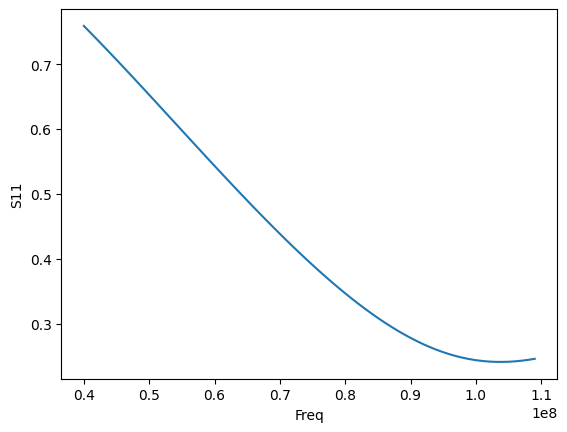

In [87]:
#Loading S11(RLC) and Frequency values
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/Users/gopipatel/Documents/RRI_VSP/saras3_S11_200mm_above_water.s1p", skiprows=5))
d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
v=[d[i][0] for i in range(len(d)-1)]


df=pd.read_csv('/Users/gopipatel/Downloads/S11_for_freq.csv')
rlc = df[df.columns[1]].values.tolist()
print(rlc)
plt.plot(v,rlc)
plt.xlabel('Freq')
plt.ylabel('S11')

In [88]:
def Compute_Tmeas_(PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    c=3*1e8
    l=l
    N=7
    freq= [d[i][0] for i in range(len(d))]
    for i in range(len(v)):
        gamma_A=p0*1e-48* freq[i] ** (N - 1) + p1*1e-39* freq[i] ** (N - 2) + p2*1e-31* freq[i] ** (N - 3) + p3*1e-23* freq[i] ** (N - 4) + p4*1e-15* freq[i] ** (N - 5) + p5*1e-08* freq[i] ** (N - 6) + p6*1e-01
        
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return Tmeas   

In [89]:
#Fixed Parameters
PA=300 
PN=70
gamma_N=0.3
f=0.1 
l = 1
s=0.01


In [93]:
########## Define the log-likelihood function
def log_likelihood(params,**args):

    PA = args["PA"]
    PN = args["PN"]
    gamma_N = args["gamma_N"]
    f = args["f"]
    l = args["l"]
    ip_params = args["ip_params"]
    s = args["s"]

    #print(PA,ip_params)

    # Compute TA expected
    
    p0, p1, p2, p3, p4, p5, p6 = ip_params
    
    np.random.seed(3)
    TA_exp = Compute_Tmeas_(PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l) + np.random.normal(0,0.001,len(v))  # Expected TA values
    TA_exp=np.array(TA_exp)
    
    # Compute model TA

    p0, p1, p2, p3, p4, p5, p6 = params
    TA_model = Compute_Tmeas_(PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l) 
    TA_model=np.array(TA_model)

    # Compute chi-squared
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 - np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior(params):

    ## Define bounds for parameters
    #min_values = [ -6,  1, -5,  3.8, -2.5,  4.5,  4]
    #if type=='open' or type=='short':
    #max_values= [-5,  3, -4,  4.8, -1.8,  5.5,  5] 
    
    p0, p1, p2, p3, p4, p5, p6 = params
    N=7
    gamma_rlc=[]
    for i in range(len(v)):
        
        gamma_value = (p0 * v[i] ** (N - 1) + 
                   p1 * v[i] ** (N - 2) + 
                   p2 * v[i] ** (N - 3) + 
                   p3 * v[i] ** (N - 4) + 
                   p4 * v[i] ** (N - 5) + 
                   p5 * v[i] ** (N - 6) + 
                   p6)
        if not (-1 <= gamma_value <= 1):
            return -np.inf  # Reject sample
        
        gamma_rlc.append(gamma_value)
        
    
    
    #for p, min_v, max_v in zip(params, min_values, max_values):
        #if not (min_v <= p <= max_v):
            #return -np.inf  # Reject sample
    return 0.0  # Uniform prior
    
######### Define the full log-probability function
    
def log_probability(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params,**args)


########## MCMC for RLC Coeffs.
def evolve_MCMC_RLC(ip_params,nsteps, initial_value):
    
    # Define parameter names
    args={"PA":PA, "PN":PN,  "gamma_N":gamma_N, "f":f, "l":l, "ip_params":ip_params, "s":s}
    parameter_names = ["PA", "p0", "p1", "p2", "p3", "p4", "p5", "p6", "PN", "gamma_N", "f", "l"]

    args=args
    
    ## Number of walkers and steps
    
    ndim = 7  # Number of parameters
    nwalkers = 200  # Number of MCMC walkers
    nsteps = nsteps  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initial_value=initial_value

    ## Starting positions for the walkers
    
    pos= initial_value + 1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*
    
    """
    ## for making sure only positive positional values
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 
    
    ## Set up the MCMC sampler
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, threads=10)
    
    ## Run MCMC
    
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=500, flat=True)

    ## Compute log-likelihoods for all samples
    
    log_likes = np.array([log_likelihood(p,**args) for p in samples])
    
    ## Find the index of the maximum likelihood
    
    max_likelihood_index = np.argmax(log_likes)
    
    ## Get the best-fit parameters
    
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params
    
    


In [94]:
#evolve MCMC for RLC parameters
ip_params=[-6.33,  2.67, -4.56,  4.17, -2.186,  5.07,  4.73]

initials=[-6,  2.4, -4.1,  4.0, -1.96,  4.7,  4.5] 

nsteps=3000

print(type(args))
full_samples, samples, best_fit_params= evolve_MCMC_RLC(ip_params,nsteps=nsteps, initial_value=initials)

<class 'dict'>
Running MCMC...


  0%|                                                  | 0/3000 [00:00<?, ?it/s]/Users/gopipatel/my_env/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 3000/3000 [00:02<00:00, 1347.75it/s]


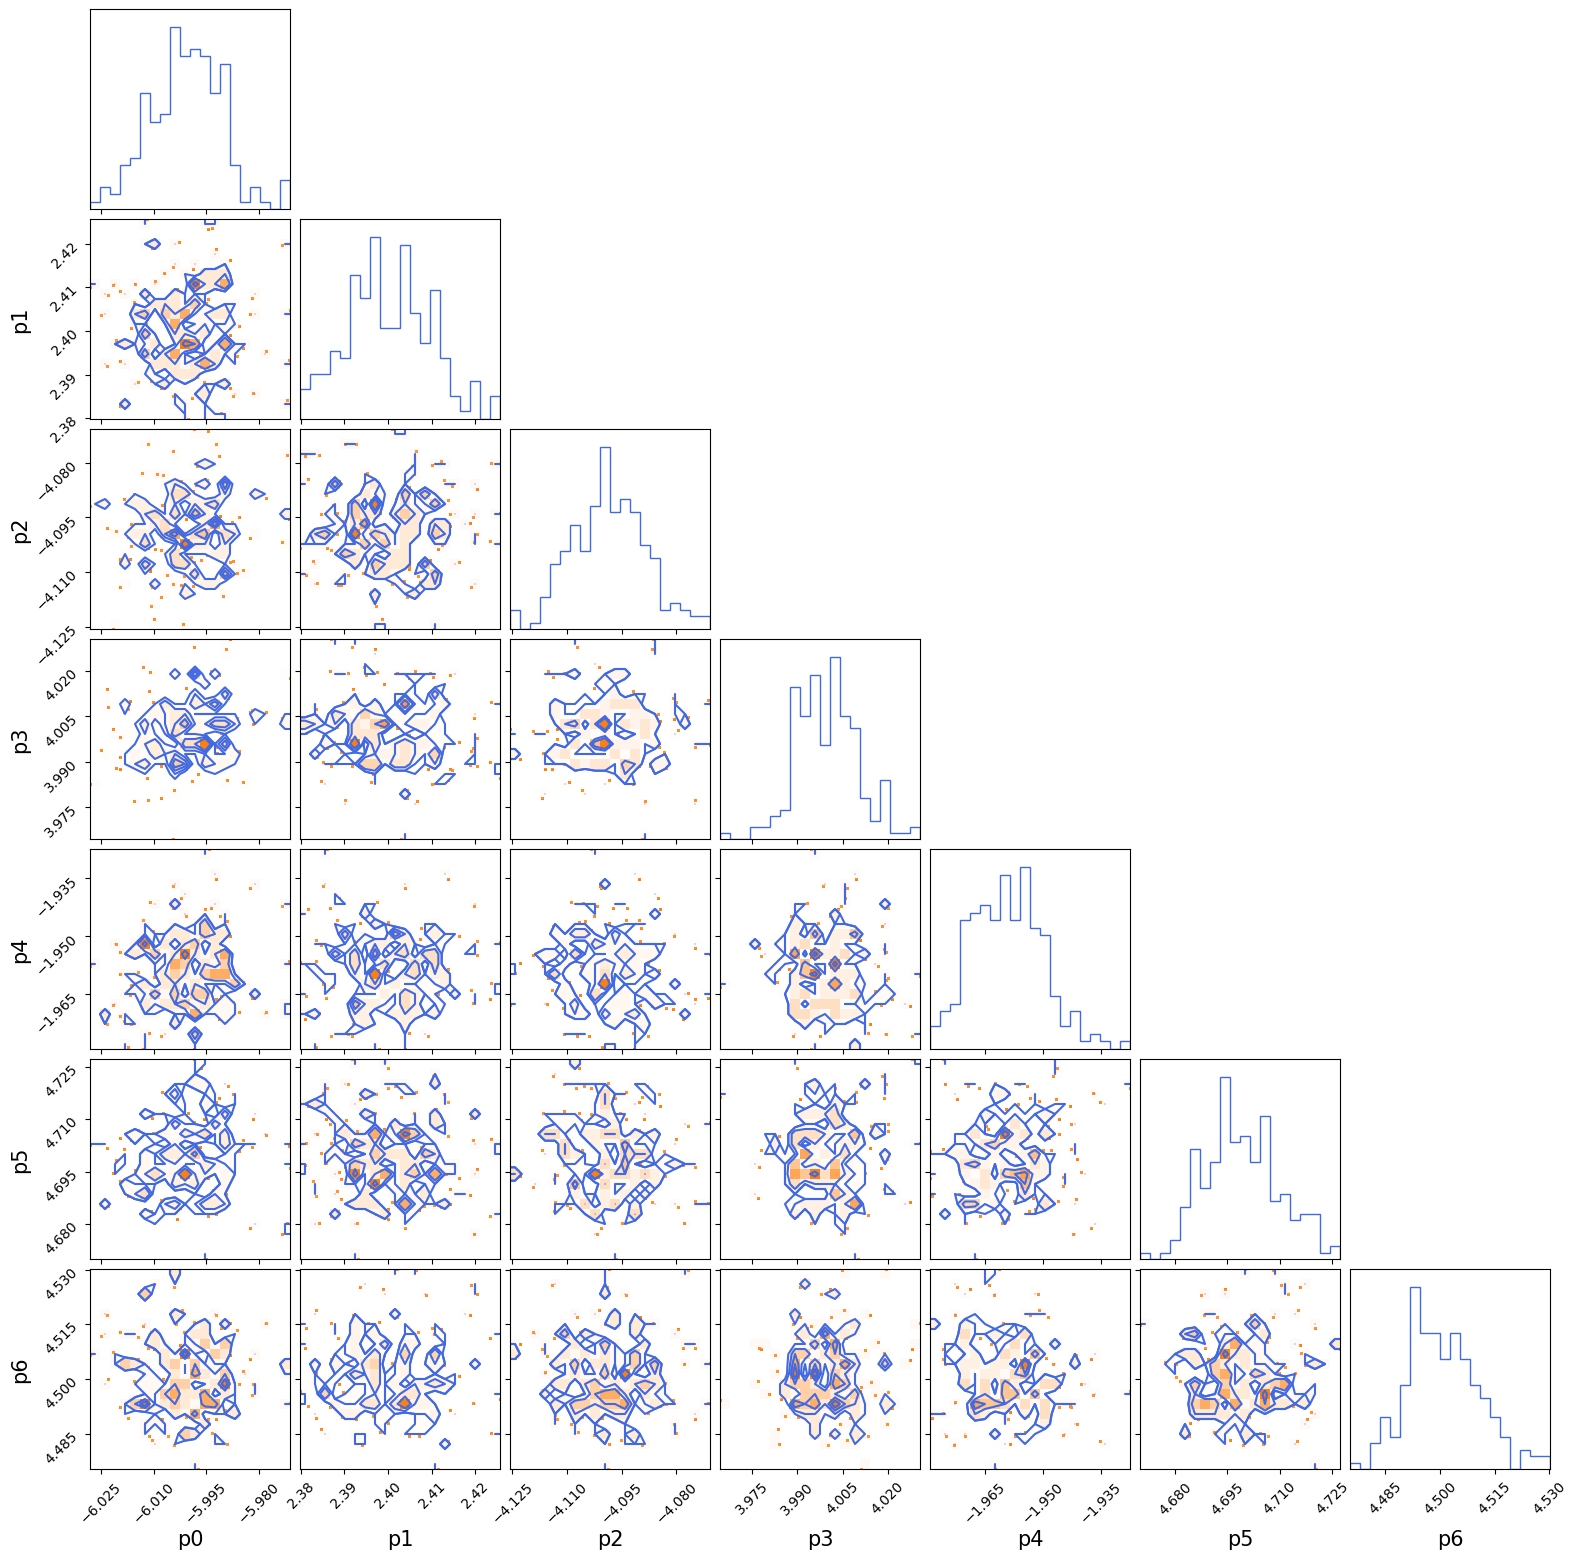

Best-fit parameters (Maximum Likelihood Estimate): [-6.019605006429897, 2.3828784494522863, -4.107083096269047, 3.9914493481671256, -1.9708456801658851, 4.69239186692399, 4.504329319967963]


In [92]:
parameter_names = ["p0", "p1", "p2", "p3", "p4", "p5", "p6"]
#corner plot 
fig = corner.corner(samples, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
label_kwargs={"fontsize":15}, #set label size
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
#plt.savefig('/Users/gopipatel/Desktop/RLC_1m.png', dpi=300)
#plt.savefig('Art.png')

plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params)